In [ ]:

import numpy as np
import pandas as pd
from scipy.stats import norm, poisson, expon, uniform, binom, beta, halfnorm, multivariate_normal

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import arviz as az
import colorsys
from matplotlib.colors import LinearSegmentedColormap


import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"
    
from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140


experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

# our frmes of intrest are only
er = e[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

# ds
ds = d[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

er[np.isnan(er)] = 90
ds[np.isnan(ds)] = 0

# min max scale err
er = er / 180

emissions = jnp.array(np.stack([ds, er], axis=-1))

subset_idx = np.random.choice(np.arange(0, len(emissions)), 400, replace=False)
sub_em = emissions[subset_idx]

er.shape, np.isnan(er).any(), ds.shape, np.isnan(ds).any(), emissions.shape

((34560, 239), np.False_, (34560, 239), np.False_, (34560, 239, 2))

## Loading the model params

In [4]:
with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)
    
with open('./caches/crossval_results.pkl', 'rb') as f:
    crossval_results = pickle.load(f)
    
with open('./caches/subject_params.pkl', 'rb') as f:
    subject_params = pickle.load(f)
    
with open('./caches/cond_params.pkl', 'rb') as f:
    cond_params = pickle.load(f)
    
with open('./caches/ml_states.pkl', 'rb') as f:
    ml_states = pickle.load(f)

# VAL VIZ

## Viz crossval

In [5]:
all_cv = []
all_ll = []

for idx in crossval_results.keys():
    sb = []
    ll = []
    for nstate in crossval_results[idx].keys():
        sb.append(crossval_results[idx][nstate].mean())
        ll.append(crossval_results[idx][nstate])
    all_cv.append(sb)
    all_ll.append(ll)

all_cv = np.array(all_cv)
all_ll = np.array(all_ll)

In [6]:
all_ll.shape

(12, 8, 100)

/tmp/ipykernel_257762/1273252595.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


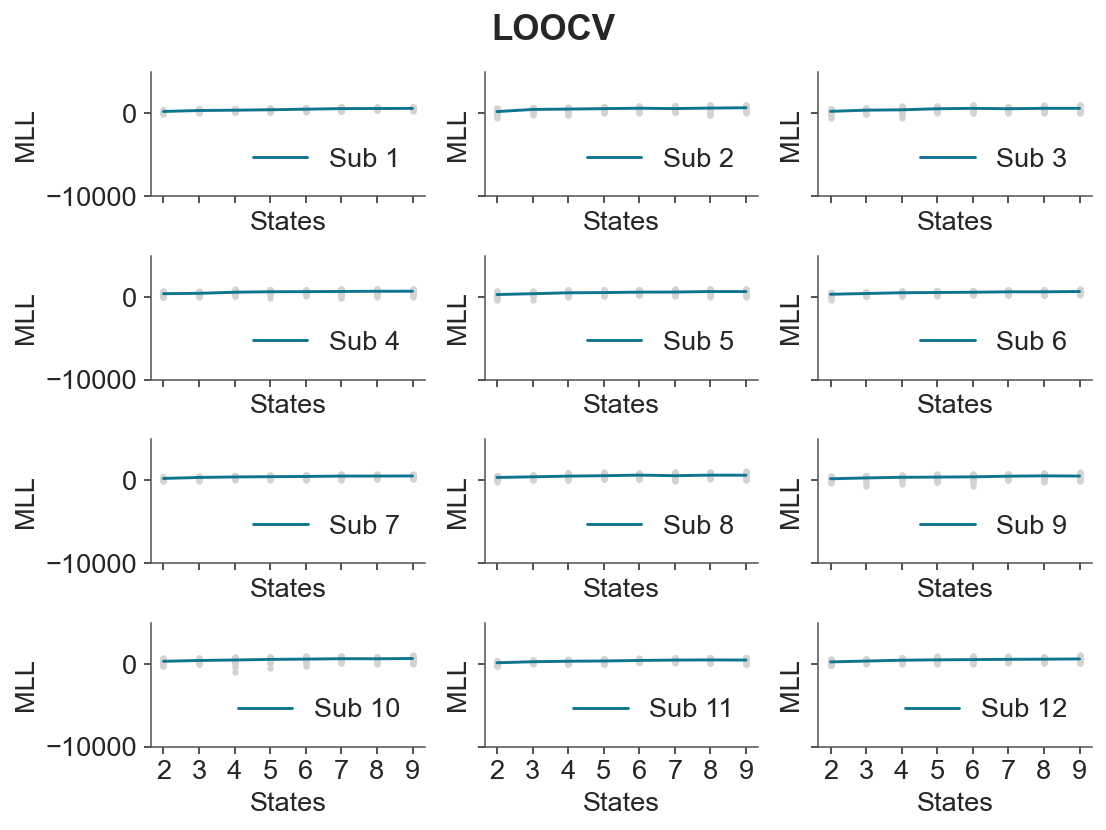

In [7]:

fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

for idx, subjects in enumerate(all_ll):
    for x in np.arange(2, 10):
        ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, subjects in enumerate(all_cv):
    # plt.plot(np.arange(2, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(2, 10), subjects, alpha=1, label=f"Sub {idx+1}")
    ax[idx].legend(frameon=False, loc="lower right")
    ax[idx].set_xticks(np.arange(2, 10))
    
    ax[idx].set_ylim(-10000,5000)
    
    ax[idx].set_ylabel("MLL")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

plt.tight_layout()

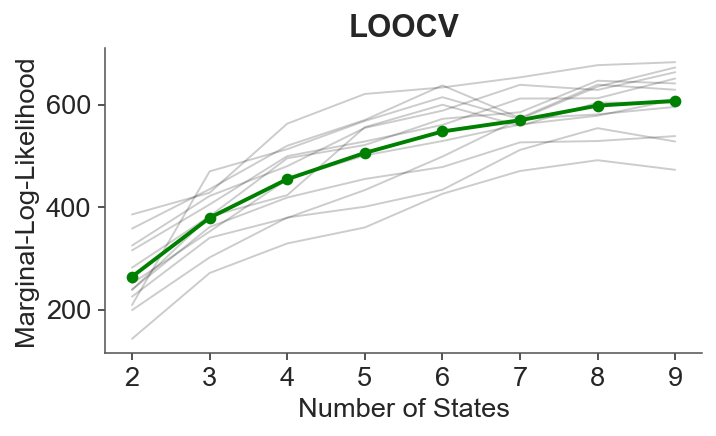

In [8]:
plt.figure(figsize=(5, 3))

# for subjects in all_ll:
#     for x in np.arange(2, 10):
#         plt.scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=0.05, color="lightgray")

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(2, 10), subjects, "-k", alpha=0.2, linewidth=1)
    # plt.plot(np.arange(2, 10), subjects, alpha=1, label=f"{idx+1}")

plt.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="Mean", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(2, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

# plt.legend()
plt.show()

## AIC, Bic of cross val

In [9]:
all_aic, all_bic = [], []
for idx, subjects in enumerate(all_ll):
    aic, bic = [], []
    for i, (n_state, ll) in enumerate(zip(np.arange(2,10), subjects)):
        T = 239
        edim = 2
        a, b = calc_aic_bic_ghmm(n_state, ll, edim, T)
        # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
        aic.append(a)
        bic.append(b)
    all_aic.append(aic)
    all_bic.append(bic)
all_aic, all_bic = np.array(all_aic), np.array(all_bic)

/tmp/ipykernel_257762/2968323393.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


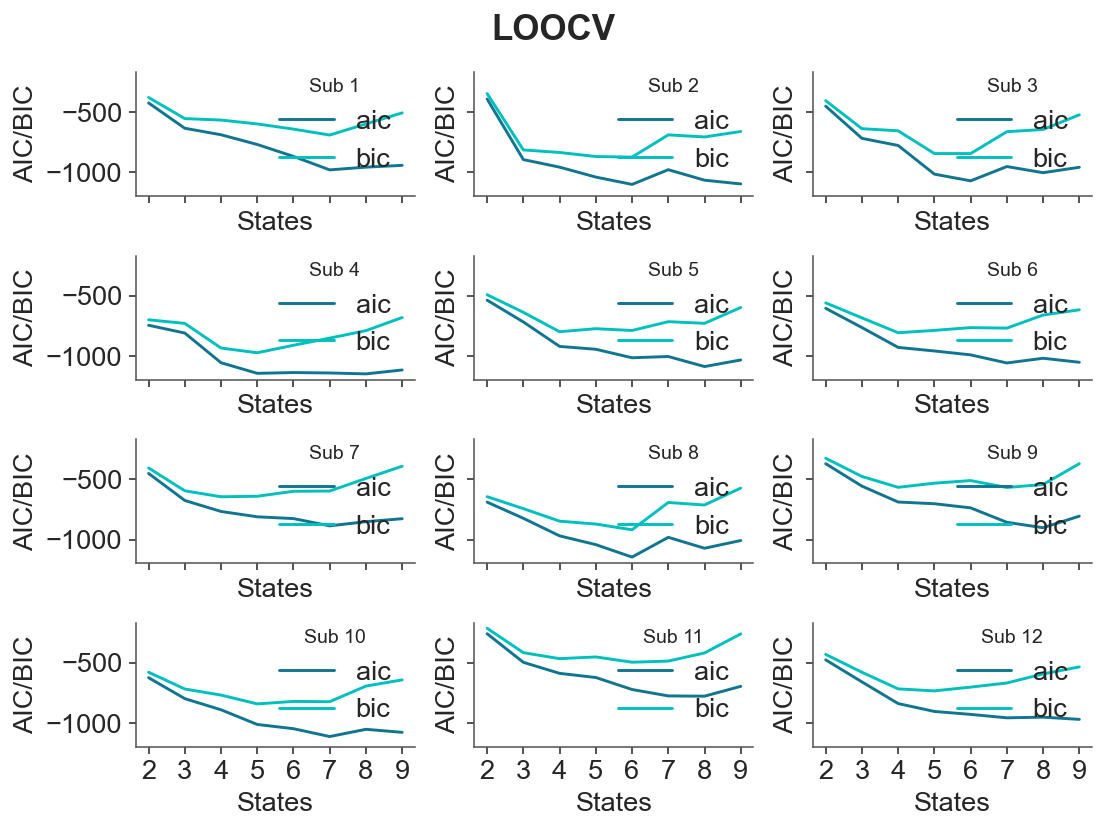

In [10]:
fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

# for idx, subjects in enumerate(all_ll):
#     for x in np.arange(2, 10):
#         ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, (aic, bic) in enumerate(zip(all_aic, all_bic)):
    # plt.plot(np.arange(2, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(2, 10), aic.mean(axis=1), alpha=1, label=f"aic")
    ax[idx].plot(np.arange(2, 10), bic.mean(axis=1), alpha=1, label=f"bic")
    
    ax[idx].legend(frameon=False, loc="lower right", title = f"Sub {idx+1}")
    ax[idx].set_xticks(np.arange(2, 10))
    
    ax[idx].set_ylabel("AIC/BIC")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

plt.tight_layout()

In [11]:
all_cv.shape, all_aic.shape, all_bic.shape

((12, 8), (12, 8, 100), (12, 8, 100))

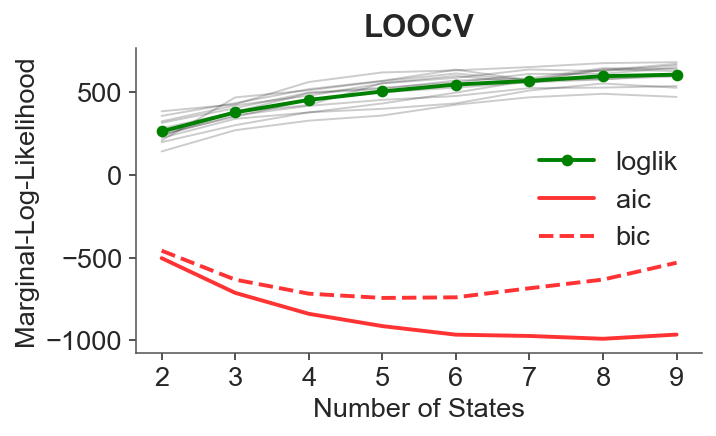

In [12]:
plt.figure(figsize=(5, 3))

# for subjects in all_ll:
#     for x in np.arange(2, 10):
#         plt.scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=0.05, color="lightgray")

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(2, 10), subjects, "-k", alpha=0.2, linewidth=1)
    # plt.plot(np.arange(2, 10), subjects, alpha=1, label=f"{idx+1}")

plt.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="loglik", linewidth=2, markersize=5)
plt.plot(np.arange(2, 10), np.array(all_aic).mean(axis=(0,2)), "-r", alpha=.8, label="aic", linewidth=2, markersize=5)
plt.plot(np.arange(2, 10), np.array(all_bic).mean(axis=(0,2)), "--r", alpha=.8, label="bic", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(2, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

plt.legend()
plt.show()

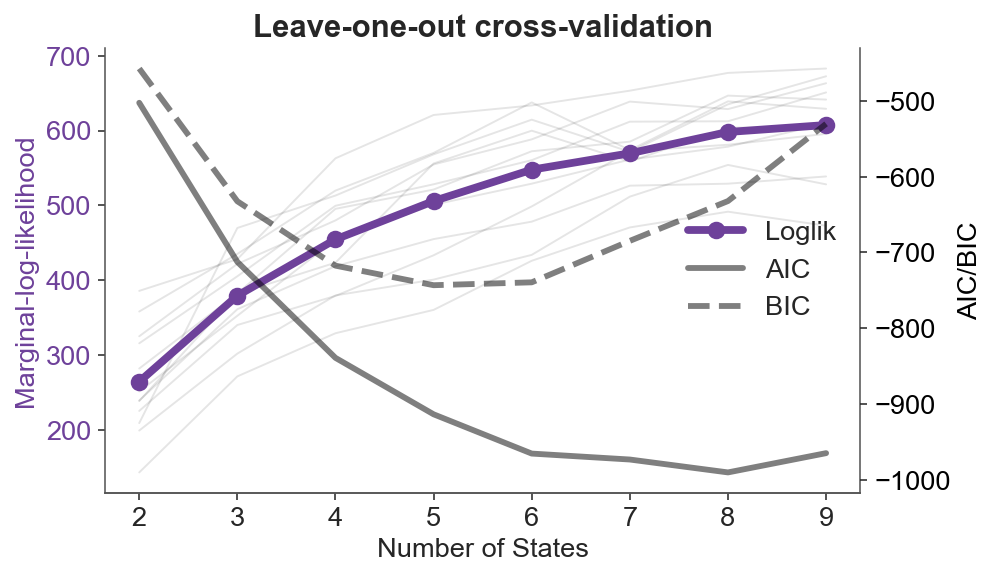

In [58]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot each individual log-likelihood curve on ax1 (left axis)
for subjects in all_cv:
    ax1.plot(np.arange(2, 10), subjects, "-k", alpha=0.1, linewidth=1)

col = "#6e419a"
# Plot the mean log-likelihood on ax1 in green
ax1.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-o", color=col,
         alpha=1, label="Loglik", linewidth=4, markersize=8)
ax1.set_xlabel("Number of States")
ax1.set_ylabel("Marginal-log-likelihood", color=col)
ax1.tick_params(axis='y', labelcolor=col)
ax1.set_xticks(np.arange(2, 10))
ax1.set_title("Leave-one-out cross-validation")

# Create a second y-axis sharing the same x-axis for AIC/BIC
ax2 = ax1.twinx()
ax2.plot(np.arange(2, 10), np.array(all_aic).mean(axis=(0,2)), "-k", 
         alpha=0.5, label="AIC", linewidth=3, markersize=5)
ax2.plot(np.arange(2, 10), np.array(all_bic).mean(axis=(0,2)), "--k", 
         alpha=0.5, label="BIC", linewidth=3, markersize=5)
ax2.set_ylabel("AIC/BIC", color="k")
ax2.tick_params(axis='y', labelcolor="k")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

# Axis border off
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

# plt.show()
plt.savefig("loocv.svg", format="svg", transparent=True)


# PARAM VIZ

In [14]:
def adjust_color_hls(color, factor=1.0):
    """
    Lighten or darken a color while maintaining its hue and saturation.
    Args:
        color (str or tuple): Base color in any Matplotlib-compatible format.
        factor (float): Factor by which to adjust the lightness. >1 darkens, <1 lightens.
    Returns:
        tuple: Adjusted color in RGBA format.
    """
    # Convert the color to RGB and then to HLS
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    
    # Adjust the lightness
    l = max(0, min(1, l * factor))
    
    # Convert back to RGB
    adjusted_rgb = colorsys.hls_to_rgb(h, l, s)
    return adjusted_rgb

# Example usage
# light_orange = adjust_color_hls("orange", factor=1.4)  # Lighter orange
# dark_orange = adjust_color_hls("orange", factor=1)   # Darker orange

# light_blue = adjust_color_hls("blue", factor=1.4)  # Lighter blue
# dark_blue = adjust_color_hls("blue", factor=1)   # Darker blue

light_orange = "lightgray"
dark_orange = "gray"

# light_blue = "#fe7070"
# dark_blue = "#b34f4f"
light_blue = "#6e419a"
dark_blue = "#36204d"

# light_cols = [light_blue, light_orange]
# dark_cols = [dark_blue, dark_orange]
light_cols = ["#6e419a", "gray"] # salmon, purp
dark_cols = ["#36204d", "lightgray"]

# light_cols = ["#fe7070", "#9391ff"] # salmon, purp
# dark_cols = ["#b34f4f", "#6766b3"]

#9391ff - purp
#6766b3 - dark purp

#fe7070 - salmon
#b34f4f - dark salmon


In [38]:


# Data: Means and Covariances
def viz_gauss_params(means, covs, ax, title=""):

    # Generate a grid for plotting
    x, y = np.linspace(-0.2, 1.2, 500), np.linspace(-0.2, 1.2, 500)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    # colors = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
    # cmaps = ["Blues", "Oranges", "Greens", "Reds", "Purples", "copper", "pink", "gray", "olive", "cividis"]
    colors = ["salmon", "gray", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
    cmaps = ["Reds", "Grays", "Greens", "Reds", "Purples", "copper", "pink", "gray", "olive", "cividis"]
    labels = ["Decision state", "Accumulation state", "3", "4", "5", "6", "7", "8", "9", "10"]
    
    # Define your custom color and colormap
    custom_color = "#6e419a"
    custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [ "white", custom_color])

    # Update the first element in your lists
    colors[0] = custom_color
    cmaps[0] = custom_cmap
    for i in range(means.shape[0]):
        rv = multivariate_normal(mean=means[i], cov=covs[i])
        Z = rv.pdf(pos)
        ax.contourf(X, Y, Z, levels=50, cmap=cmaps[i], alpha=0.3)
        ax.contour(X, Y, Z, levels=10, colors=colors[i], linewidths=.6, alpha=0.8)
        ax.scatter(means[i, 0], means[i, 1], c=colors[i], s=100, marker="x", label=f"{labels[i]}")
    
    # Labels and legend
    ax.set_title(title)

    ax.set_ylim(0,1)
    ax.set_xlim(0,1)

    # Apply y-ticks formatting similar to the plt.yticks() example
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(y*180)}" for y in ax.get_yticks()])  # Format y-tick labels

    ax.legend(loc='upper right')

## Global params viz

In [39]:
emissions.shape

(34560, 239, 2)

In [40]:
r_table[r_table["subj"] == 2]

,Unnamed: 0,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,...,nn,1sig,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir
2880,2880,2,0,0,0,159.0,140.875874,142.594376,1.718503,1.718503,...,140.875874,1.0,1.0,1.0,focused,low,expected,168,339,higher
2881,2881,2,0,0,1,159.0,140.875874,127.988431,12.887443,-12.887443,...,132.996473,0.0,0.0,0.0,focused,high,expected,120,429,lower
2882,2882,2,0,0,2,159.0,140.875874,135.511923,5.363951,-5.363951,...,132.996473,1.0,1.0,0.0,focused,high,expected,120,343,lower
2883,2883,2,0,0,3,159.0,140.875874,122.828388,18.047486,-18.047486,...,132.996473,0.0,0.0,0.0,divided,high,expected,180,382,lower
2884,2884,2,0,0,4,159.0,140.875874,34.677449,106.198425,-106.198425,...,37.713817,0.0,0.0,0.0,divided,low,expected,192,387,lower
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,5755,2,3,5,115,51.0,47.456887,59.899494,12.442607,12.442607,...,69.469075,0.0,1.0,0.0,focused,high,NaN,156,333,higher
5756,5756,2,3,5,116,159.0,140.875874,132.784467,8.091407,-8.091407,...,132.996473,0.0,1.0,0.0,divided,low,NaN,144,379,lower
5757,5757,2,3,5,117,51.0,47.456887,51.894451,4.437564,4.437564,...,47.456887,1.0,1.0,1.0,divided,low,NaN,144,387,higher
5758,5758,2,3,5,118,123.0,132.996473,108.572349,24.424124,-24.424124,...,132.996473,0.0,0.0,1.0,focused,low,NaN,192,375,lower


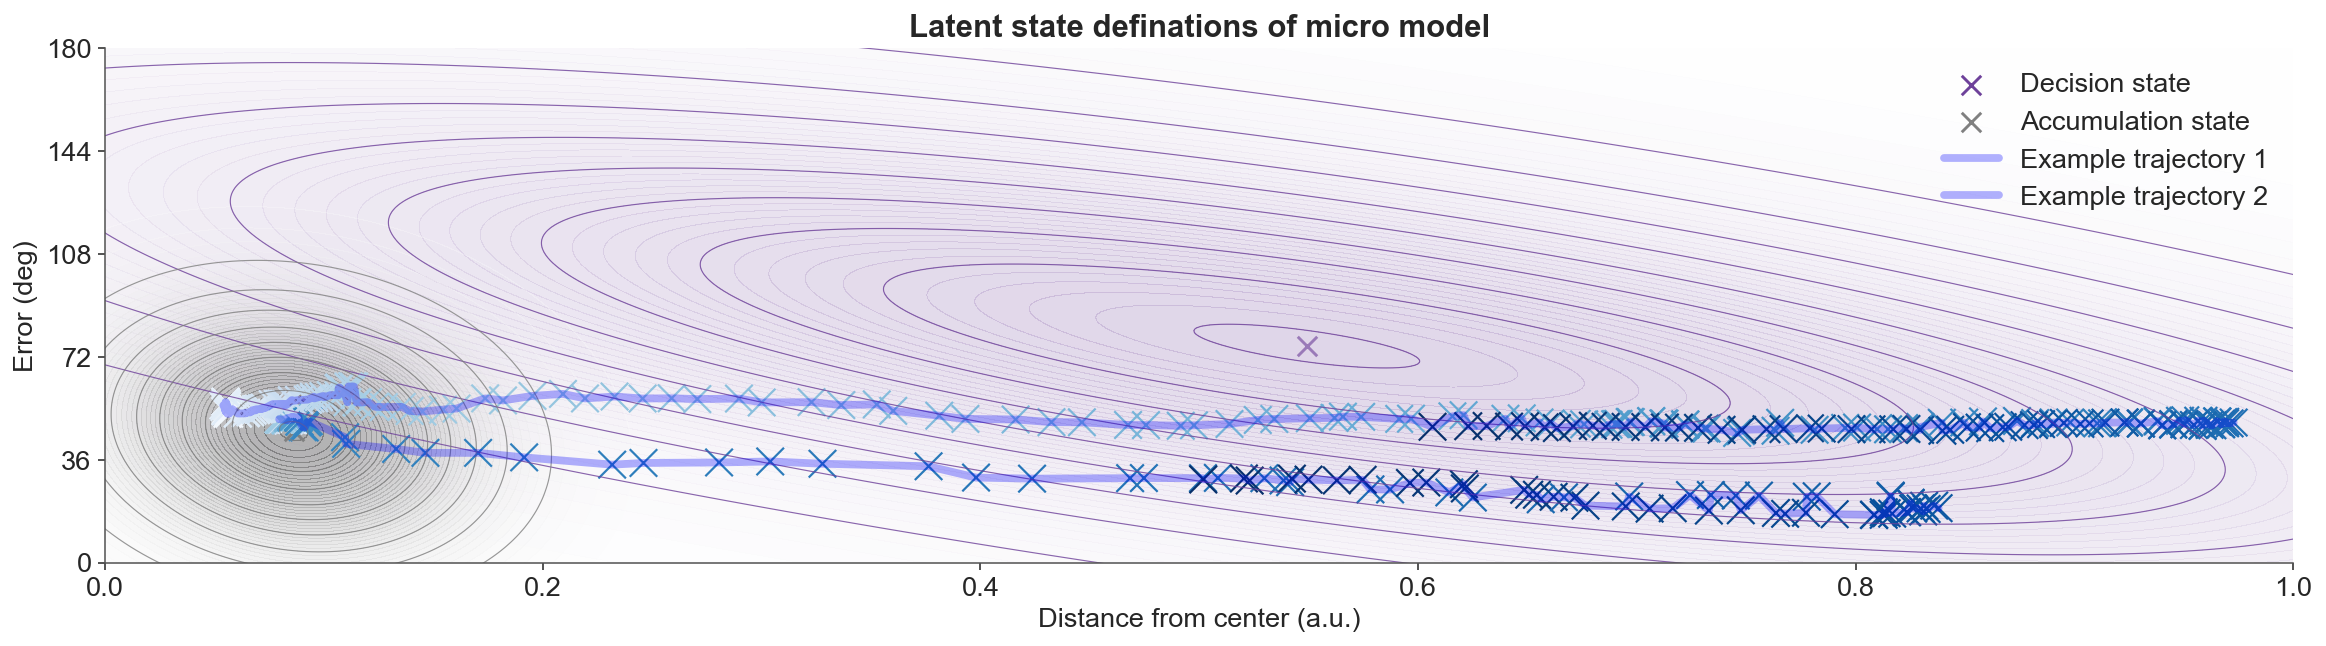

In [41]:
gp = global_params[2]

fig, ax = plt.subplots(1, 1, figsize=(11*1.5, 3*1.5))

m = gp.emissions.means
c = gp.emissions.covs
viz_gauss_params(m, c, ax, title = f"Latent state definations of micro model")
a = 5000
dd = emissions[a:a+10, :, :].mean(axis=0)
sns.lineplot(x = dd[:,0], y = dd[:,1], color="blue", ax=ax, alpha=0.3, label="Example trajectory 1", linewidth=4)
sns.scatterplot(x = dd[:,0], y = dd[:,1], c=np.arange(239), s=200, alpha=1, cmap="Blues", marker="x", ax=ax)

# Another line
a = 6700
dd = emissions[a:a+20, :, :].mean(axis=0)
sns.lineplot(x = dd[:,0], y = dd[:,1], color="blue", ax=ax, alpha=0.3, label="Example trajectory 2", linewidth=4)
sns.scatterplot(x = dd[:,0], y = dd[:,1], c=np.arange(239), s=200, alpha=1, cmap="Blues", marker="x", ax=ax)


ax.set_xlabel("Distance from center (a.u.)")
ax.set_ylabel("Error (deg)")
ax.legend()
# plt.show()
plt.savefig("lviz.svg", format="svg", transparent=True)

<Axes: >

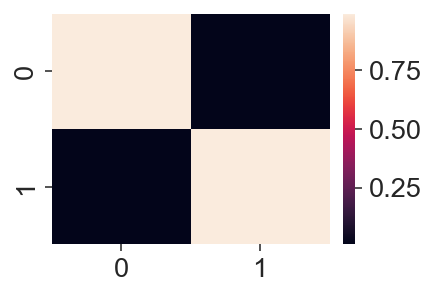

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
sns.heatmap(gp.transitions.transition_matrix)

In [20]:
gp.emissions.means,gp.emissions.covs

(Array([[0.5491672 , 0.42100167],
        [0.08617153, 0.25588247]], dtype=float32),
 Array([[[ 0.14758956, -0.08453389],
         [-0.08453389,  0.10044059]],
 
        [[ 0.00314847, -0.00123707],
         [-0.00123707,  0.0249726 ]]], dtype=float32))

In [21]:
# plt.figure(figsize=(4,3))
# sns.heatmap(ts.transitions.transition_matrix)

## Subj params viz

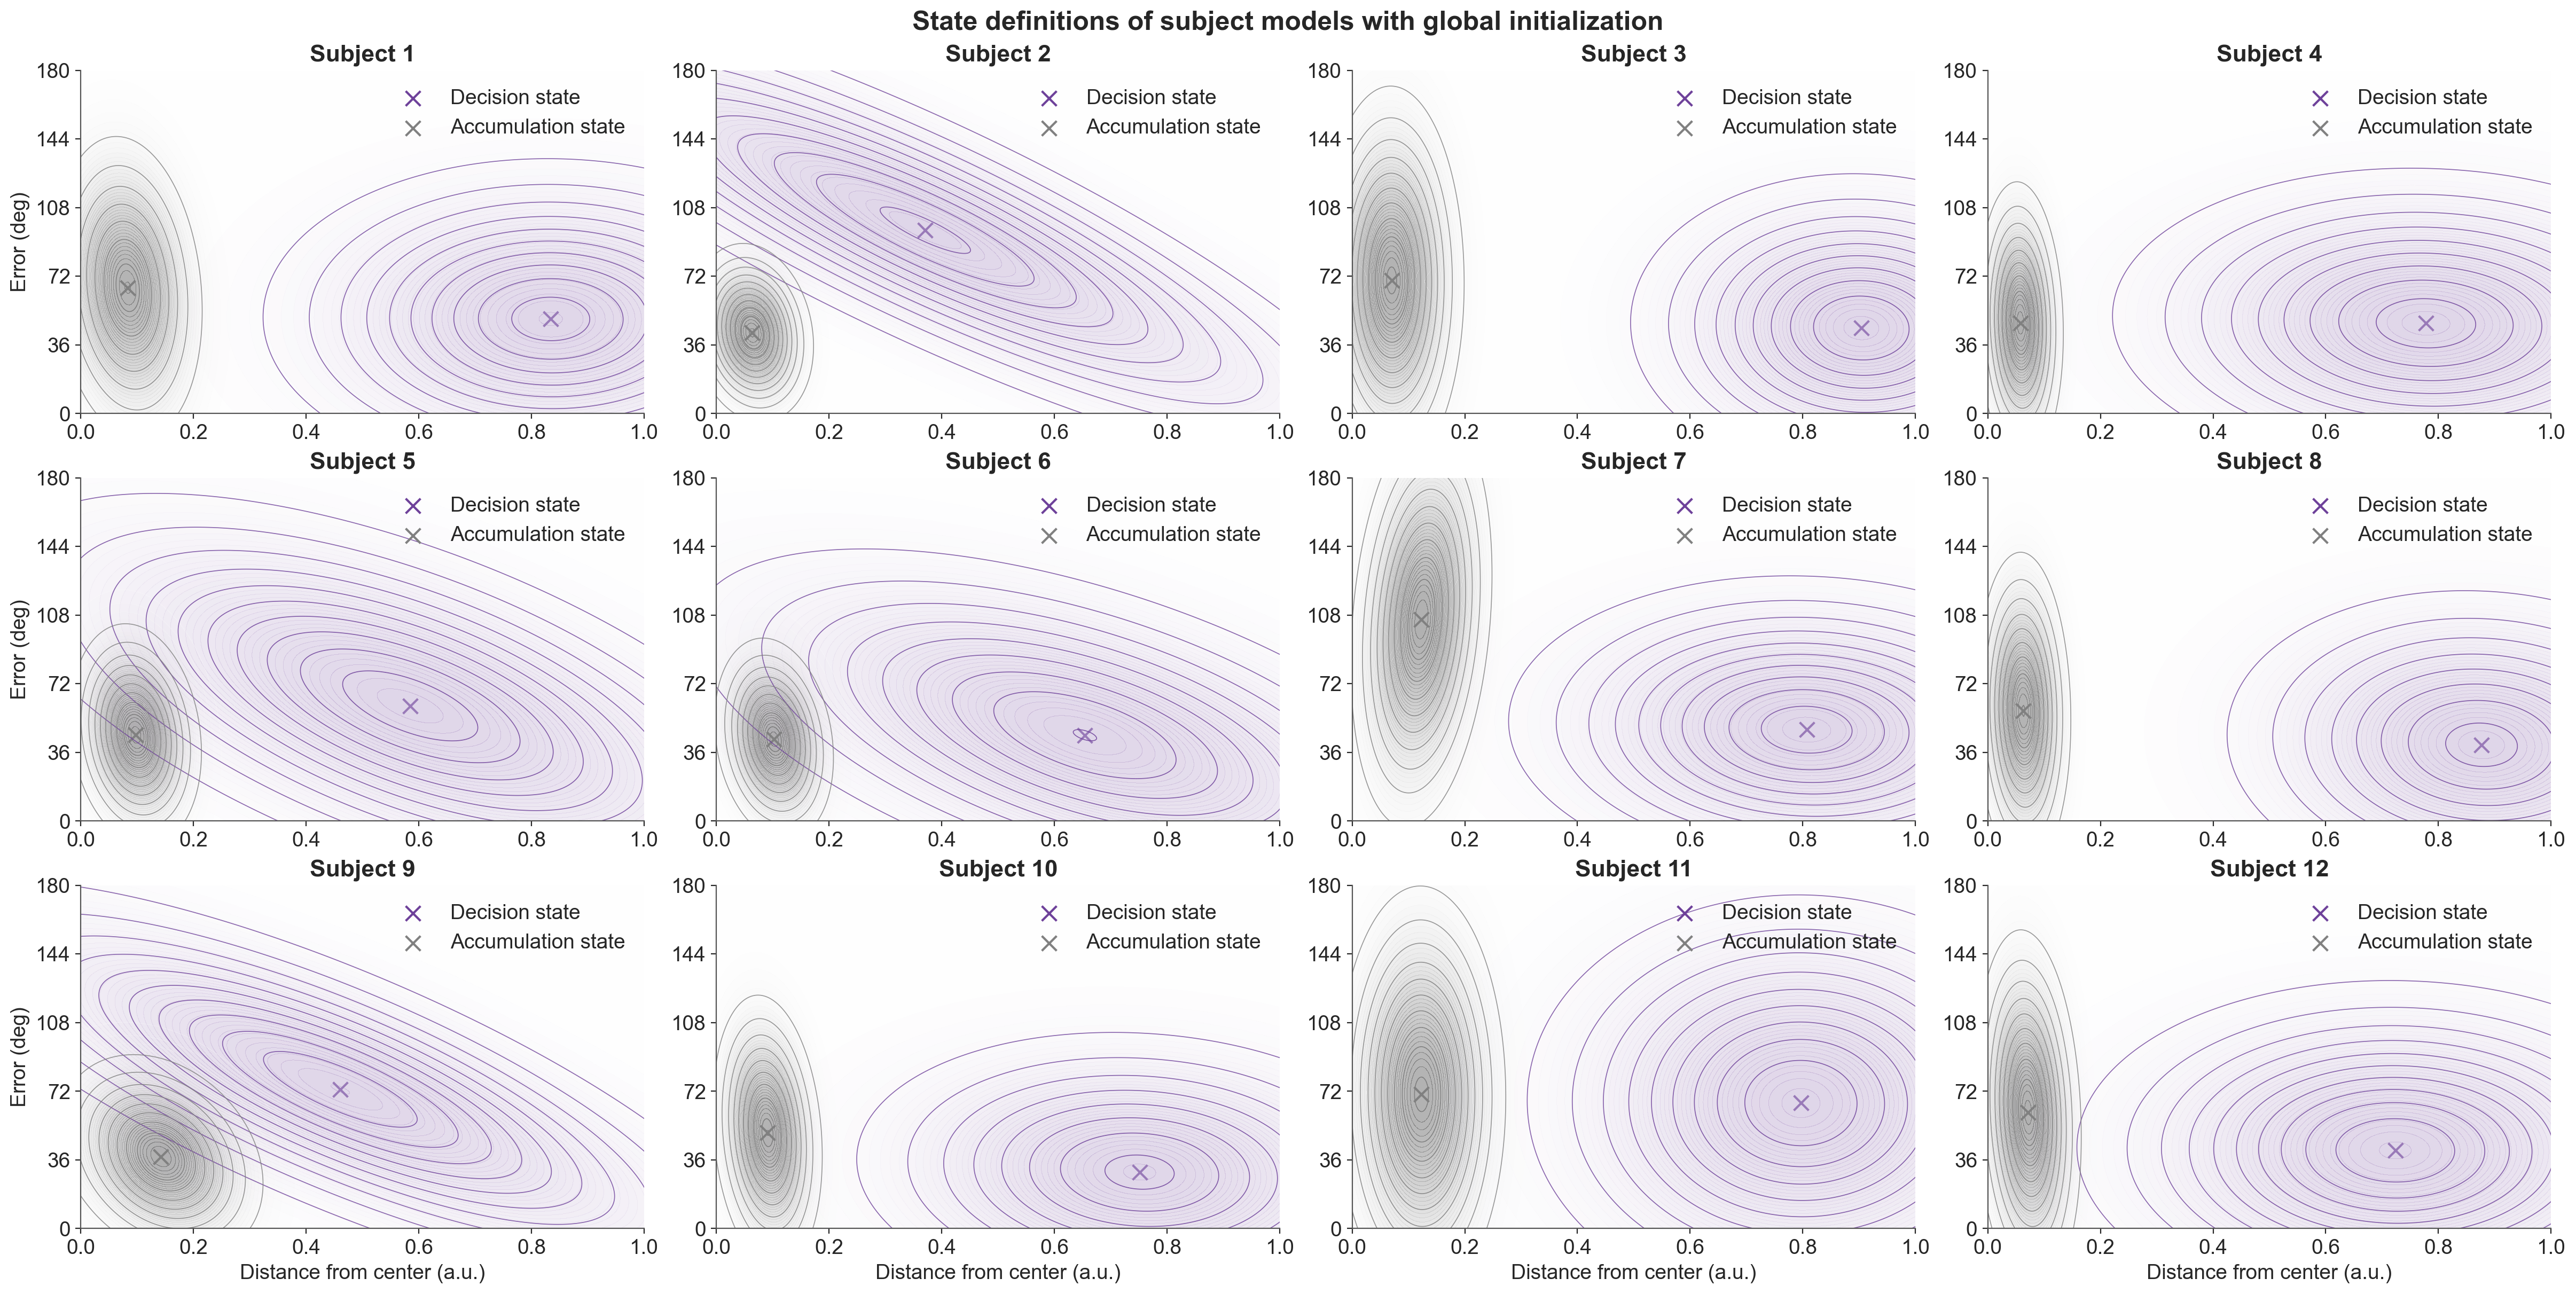

In [43]:
s_params = [subject_params[i] for i in range(12)]

fig, ax = plt.subplots(3, 4, figsize=(6*4, 4*3), dpi=200)
for idx, s_par in enumerate(s_params):
    m = s_par.emissions.means
    c = s_par.emissions.covs
    viz_gauss_params(m, c, ax.flatten()[idx], title = f"Subject {idx+1}")

for a in ax[:, 0].flatten():
    a.set_ylabel("Error (deg)")

for a in ax[2,:].flatten():
    a.set_xlabel("Distance from center (a.u.)")

# ax[0,3].legend(loc='upper right')
plt.suptitle("State definitions of subject models with global initialization")
plt.show()

In [23]:
tm, tc = [], []
for s_par in s_params:
    tm.append(s_par.emissions.means)
    tc.append(s_par.emissions.covs)
    
tm = np.array(tm)
tc = np.array(tc)

tm.shape, tc.shape

((12, 2, 2), (12, 2, 2, 2))

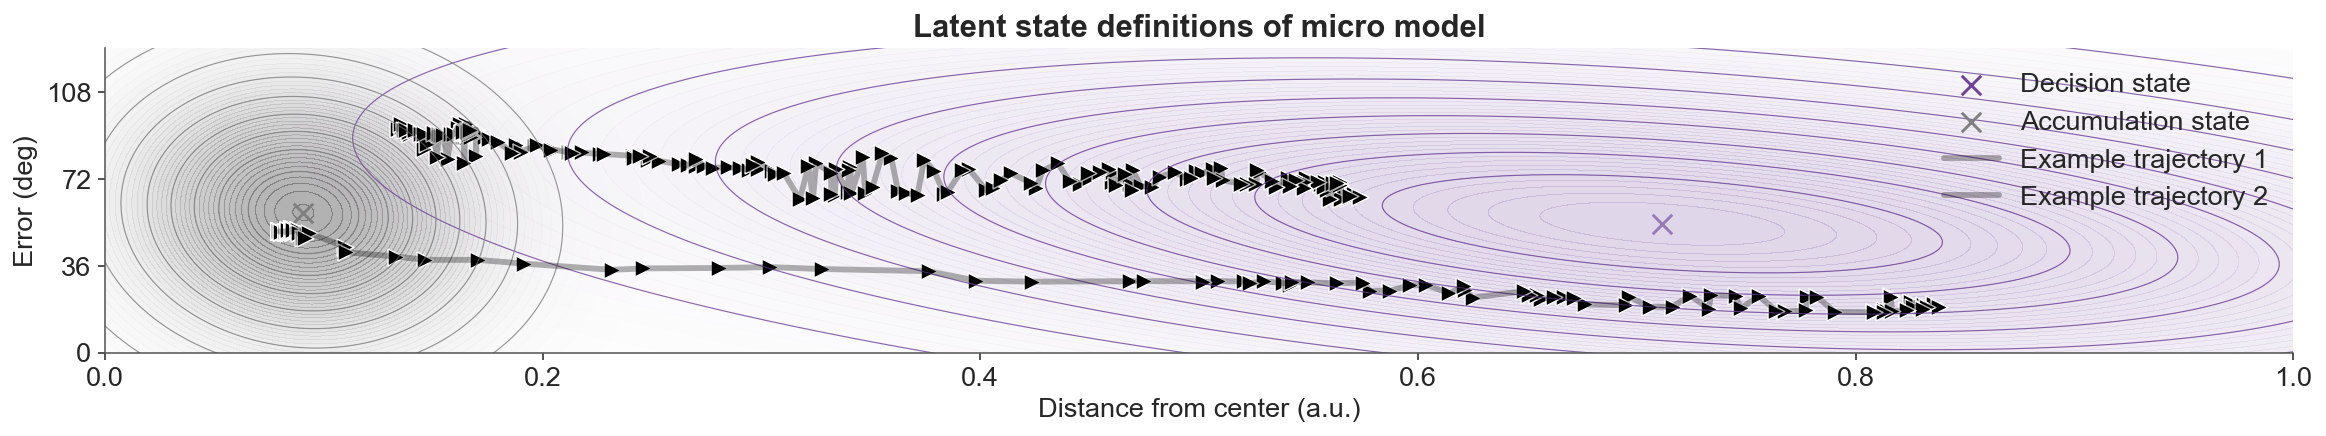

In [44]:
gp = global_params[2]

fig, ax = plt.subplots(1, 1, figsize=(11*1.5, 3))

m = tm.mean(axis=0)
c = tc.mean(axis=0)
viz_gauss_params(m, c, ax, title = f"Latent state definitions of micro model")
a = 5000
dd = emissions[a:a+10, :, :].mean(axis=0)
sns.lineplot(x = dd[:,0], y = dd[:,1], color="black", ax=ax, alpha=0.3, label="Example trajectory 1", linewidth=3)
sns.scatterplot(x = dd[:,0], y = dd[:,1], s=75, alpha=1, marker=">", ax=ax, color="black")

# Another line
a = 20000
dd = emissions[a:a+20, :, :].mean(axis=0)
sns.lineplot(x = dd[:,0], y = dd[:,1], color="black", ax=ax, alpha=0.3, label="Example trajectory 2", linewidth=3)
sns.scatterplot(x = dd[:,0], y = dd[:,1], s=75, alpha=1, marker=">", ax=ax, color="black")


ax.set_xlabel("Distance from center (a.u.)")
ax.set_ylabel("Error (deg)")
ax.legend()
# plt.show()
ax.set_ylim(0,0.7)
plt.savefig("lviz.svg", format="svg", transparent=True)

## Condtion params viz

In [46]:
conditions = ["low", "high", "divided", "focused", "unexpected", "expected"]

In [47]:
flat_cond_params = {}

for cond in cond_params.keys():
    cc = []
    for subject in cond_params[cond].keys():
        cc.append(cond_params[cond][subject])
    flat_cond_params[cond] = cc

In [48]:
p_low_coh = flat_cond_params["low"]
p_high_coh = flat_cond_params["high"]
p_div = flat_cond_params["divided"]
p_att = flat_cond_params["focused"]
p_exp = flat_cond_params["expected"]
p_unexp = flat_cond_params["unexpected"]

In [49]:
def get_mean_cov(p, mean=True):
    all_means = []
    all_covs = []
    for i in range(12):
        all_means.append(p[i].emissions.means)
        all_covs.append(p[i].emissions.covs)

    all_means = np.array(all_means)
    all_covs = np.array(all_covs)
    if not mean:
        return all_means, all_covs
    else:
        return np.mean(all_means, axis=0), np.mean(all_covs, axis=0)

In [50]:
# Data: Means and Covariances
def viz_gauss_params(means, covs, ax, title="", l1 = 'Anticipation state', l2 = 'Action state', c1 = 'blue', c2 = 'orange', m = "x"):

    # Generate a grid for plotting
    x, y = np.linspace(-0.2, 1.2, 500), np.linspace(-0.2, 1.2, 500)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    # Compute Gaussian densities
    rv1 = multivariate_normal(mean=means[0], cov=covs[0])
    rv2 = multivariate_normal(mean=means[1], cov=covs[1])
    Z1 = rv1.pdf(pos)
    Z2 = rv2.pdf(pos)

    # make gradual cmap of color to white
    # c1cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["white", c1])
    # c2cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["white", c2])
    # # Heatmaps
    # ax.contourf(X, Y, Z1, levels=50, cmap=c1cmap, alpha=0.3)
    # ax.contourf(X, Y, Z2, levels=50, cmap=c2cmap, alpha=0.3)
    
    # Define your custom color and colormap
    # custom_color = "#6e419a"
    c1cmap = LinearSegmentedColormap.from_list("custom_cmap", [ "white", c1])
    c2cmap = LinearSegmentedColormap.from_list("custom_cmap", [ "white", c2])


    # # Contour lines
    ax.contour(X, Y, Z1, levels=10, colors=c1, linewidths=.6, alpha=0.8)
    ax.contour(X, Y, Z2, levels=10, colors='gray', linewidths=.6, alpha=0.8)

    # Scatter points for means with distinct labels
    ax.scatter(means[0, 0], means[0, 1], c=c1, s=100, marker=m, label=l1)
    ax.scatter(means[1, 0], means[1, 1], c=c2, s=100, marker=m, label=l2)
    
    # Labels and legend
    ax.set_title(title)

    ax.set_ylim(0,1)
    ax.set_xlim(0,1)

    # Apply y-ticks formatting similar to the plt.yticks() example
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(y*180)}" for y in ax.get_yticks()])  # Format y-tick labels

    ax.set_xlabel("Distance from center (a.u.)")
    ax.set_ylabel("Error (deg)")
    ax.legend()

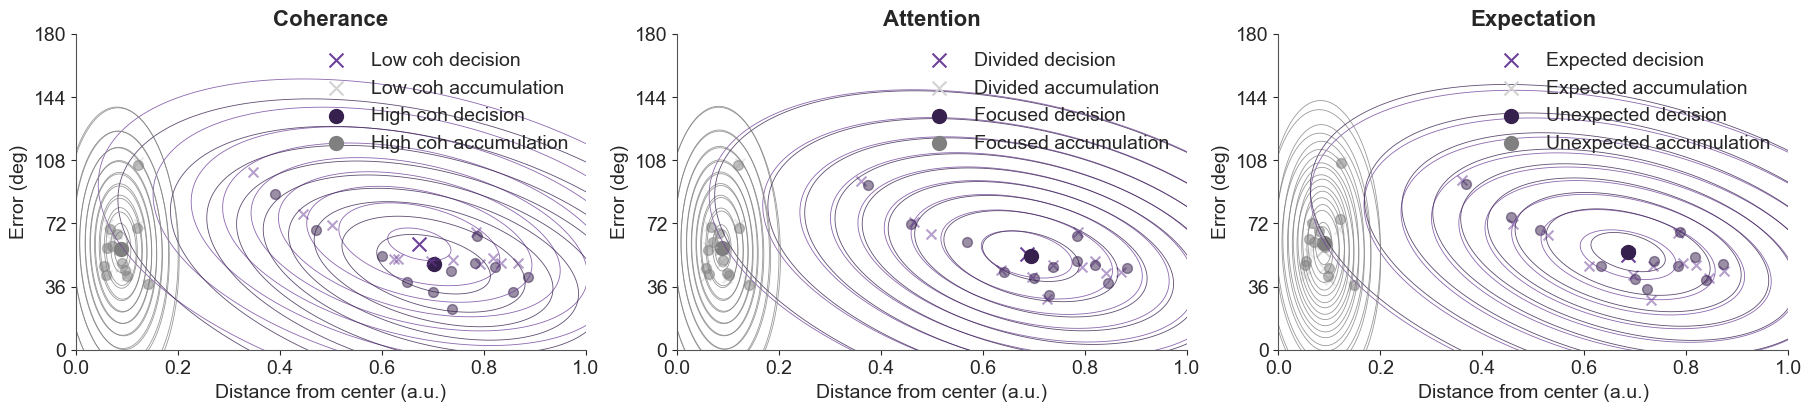

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(6*3, 4), dpi=100)

ax_coh = ax[0]
ax_att = ax[1]
ax_exp = ax[2]


m, c = get_mean_cov(p_low_coh)
viz_gauss_params(m, c, ax_coh, title = f"", l1 = 'Low coh decision', l2 = 'Low coh accumulation', c1 = light_blue, c2 = light_orange, m = "x")
m, c = get_mean_cov(p_high_coh)
viz_gauss_params(m, c, ax_coh, title = f"Coherence", l1 = 'High coh decision', l2 = 'High coh accumulation', c1 = dark_blue, c2 = dark_orange, m = "o")

m, c = get_mean_cov(p_div)
viz_gauss_params(m, c, ax_att, title = f"", l1 = 'Divided decision', l2 = 'Divided accumulation', c1 = light_blue, c2 = light_orange, m = "x")
m, c = get_mean_cov(p_att)
viz_gauss_params(m, c, ax_att, title = f"Attention", l1 = 'Focused decision', l2 = 'Focused accumulation', c1 = dark_blue, c2 = dark_orange, m = "o")

m, c = get_mean_cov(p_exp)
viz_gauss_params(m, c, ax_exp, title = f"", l1 = 'Expected decision', l2 = 'Expected accumulation', c1 = light_blue, c2 = light_orange, m = "x")
m, c = get_mean_cov(p_unexp)
viz_gauss_params(m, c, ax_exp, title = f"Expectation", l1 = 'Unexpected decision', l2 = 'Unexpected accumulation', c1 = dark_blue, c2 = dark_orange, m = "o")


m, c = get_mean_cov(p_low_coh, mean=False)
# scatter these individuall means
for mm in m:
    ax_coh.scatter(mm[0, 0], mm[0, 1], c=light_blue, s=50, marker="x", alpha=0.5)
    ax_coh.scatter(mm[1, 0], mm[1, 1], c=light_orange, s=50, marker="x", alpha=0.5)

m, c = get_mean_cov(p_high_coh, mean=False)
# scatter these individuall means
for mm in m:
    ax_coh.scatter(mm[0, 0], mm[0, 1], c=dark_blue, s=50, marker="o", alpha=0.5)
    ax_coh.scatter(mm[1, 0], mm[1, 1], c=dark_orange, s=50, marker="o", alpha=0.5)


m, c = get_mean_cov(p_div, mean=False)
# scatter these individuall means
for mm in m:
    ax_att.scatter(mm[0, 0], mm[0, 1], c=light_blue, s=50, marker="x", alpha=0.5)
    ax_att.scatter(mm[1, 0], mm[1, 1], c=light_orange, s=50, marker="x", alpha=0.5)

m, c = get_mean_cov(p_att, mean=False)
# scatter these individuall means
for mm in m:
    ax_att.scatter(mm[0, 0], mm[0, 1], c=dark_blue, s=50, marker="o", alpha=0.5)
    ax_att.scatter(mm[1, 0], mm[1, 1], c=dark_orange, s=50, marker="o", alpha=0.5)

m, c = get_mean_cov(p_exp, mean=False)
# scatter these individuall means
for mm in m:
    ax_exp.scatter(mm[0, 0], mm[0, 1], c=light_blue, s=50, marker="x", alpha=0.5)
    ax_exp.scatter(mm[1, 0], mm[1, 1], c=light_orange, s=50, marker="x", alpha=0.5)

m, c = get_mean_cov(p_unexp, mean=False)
# scatter these individuall means
for mm in m:
    ax_exp.scatter(mm[0, 0], mm[0, 1], c=dark_blue, s=50, marker="o", alpha=0.5)
    ax_exp.scatter(mm[1, 0], mm[1, 1], c=dark_orange, s=50, marker="o", alpha=0.5)

# plt.show()
plt.savefig("cviz.svg", format="svg", transparent=True)

# OCCUPANCY VIZ

In [52]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
mini_axis = xaxis[start_idx:end_idx]
(start_idx, end_idx)

(np.int64(191), np.int64(430))

In [53]:
ml_concat = {}

for cond in ml_states.keys():
    cc = []
    for subject in ml_states[cond].keys():
        cc.append(ml_states[cond][subject])
    ml_concat[cond] = np.concatenate(cc, axis=0)

In [54]:
def plot_occ(ld, hd, low_name, high_name, effect, subject = None, ax = None):
    state_probs = {state: np.mean(ld == state, axis=0) for state in [0, 1]}
    for state, probs in state_probs.items():
        ax.plot(mini_axis, probs, label=[f"{low_name} accumulation", f"{low_name} decision"][state], linewidth=3, color=light_cols[state])

    state_probs = {state: np.mean(hd == state, axis=0) for state in [0, 1]}
    for state, probs in state_probs.items():
        ax.plot(mini_axis, probs, label=[f"{high_name} accumulation", f"{high_name} decision"][state], linewidth=3, color=dark_cols[state])


    # plt.ylim(0, 1)
    ax.set_xlim(-500, 1500)
    ax.set_ylim(0, 1)

    if subject: ax.set_title(f'{subject}')
    ax.set_xlabel('Time from onset (ms)')
    ax.set_ylabel('p(state)')
    # ax.legend()

    handles, labels = ax.get_legend_handles_labels()
    order = [0,2,1,3]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center left')

    ax.grid(True)
    # plt.show()

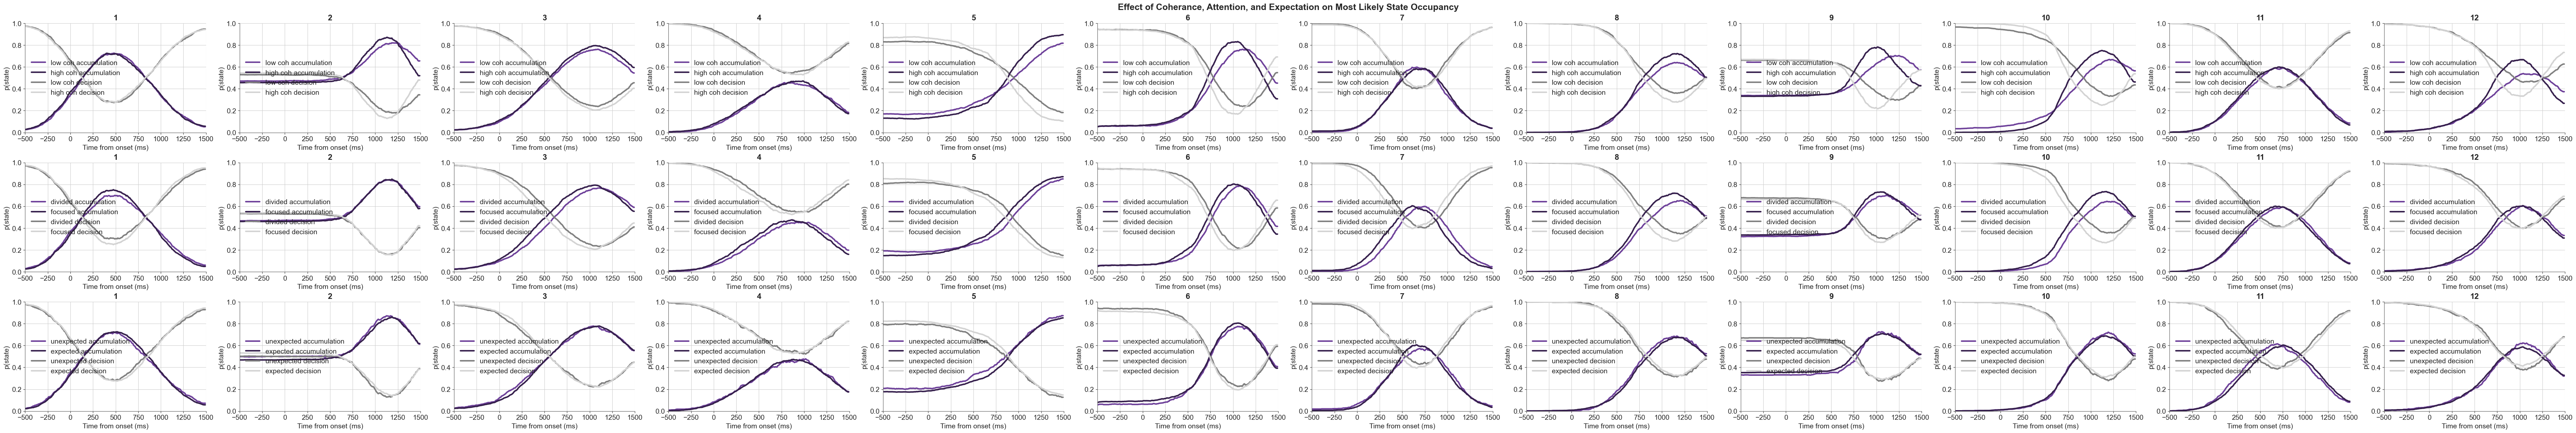

In [ ]:
fig, axs = plt.subplots(3, 12, figsize=(6*12, 4*3), dpi=100)

for idx in range(0,12):
    subject = idx%12
    a = np.array(ml_states["low"][subject])
    b = np.array(ml_states["high"][subject])

    plot_occ(a, b, "low coh", "high coh", "Coherence", subject + 1, ax = axs.flatten()[idx])

for idx in range(12, 24):
    subject = idx%12
    a = np.array(ml_states["divided"][subject])
    b = np.array(ml_states["focused"][subject])

    plot_occ(a, b, "divided", "focused", "Attention", subject + 1, ax = axs.flatten()[idx])

for idx in range(24, 36):
    subject = idx%12
    a = np.array(ml_states["unexpected"][subject])
    b = np.array(ml_states["expected"][subject])

    plot_occ(a, b, "unexpected", "expected", "Expectation", subject + 1, ax = axs.flatten()[idx])

plt.suptitle(f"Effect of Coherence, Attention, and Expectation on Most Likely State Occupancy")
plt.show()

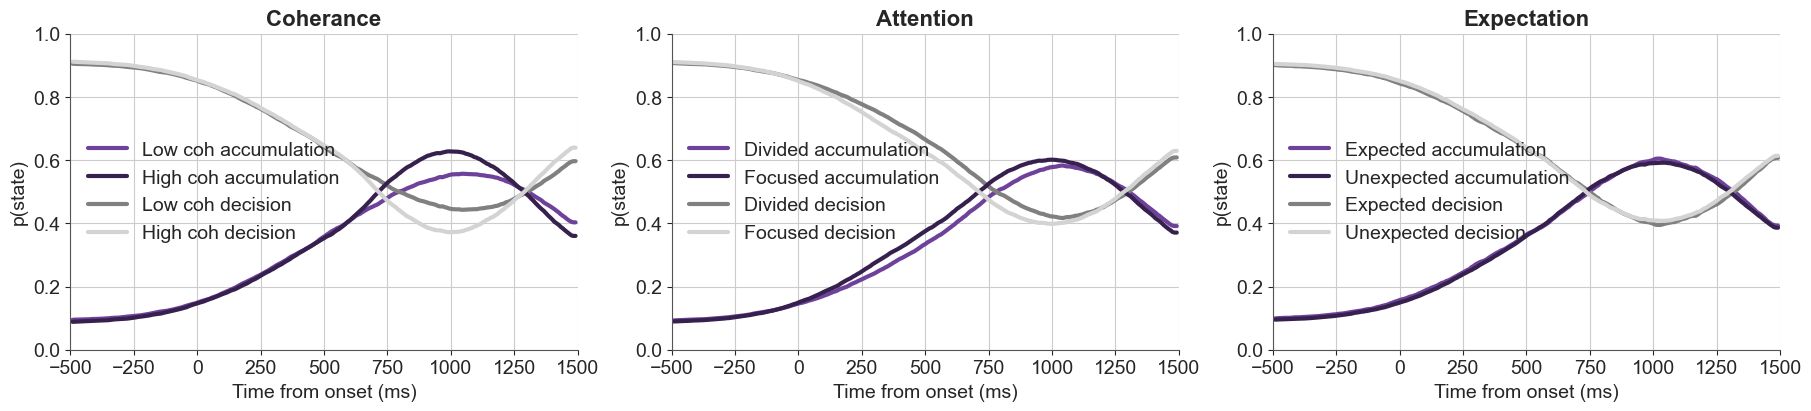

In [57]:
fig, axs = plt.subplots(1, 3, figsize=(6*3, 4*1), dpi=100)


a = np.array(ml_concat["low"]).reshape(-1, 239)
b = np.array(ml_concat["high"]).reshape(-1, 239)

plot_occ(a, b, "Low coh", "High coh", "Coherence", "Coherance", ax = axs.flatten()[0])


a = np.array(ml_concat["divided"]).reshape(-1, 239)
b = np.array(ml_concat["focused"]).reshape(-1, 239)
plot_occ(a, b, "Divided", "Focused", "Attention", "Attention", ax = axs.flatten()[1])

a = np.array(ml_concat["unexpected"])
b = np.array(ml_concat["expected"])

plot_occ(a, b, "Expected", "Unexpected", "Expectation", "Expectation", ax = axs.flatten()[2])

# plt.suptitle(f"Effect of Coherance, Attention, and Expectation on Most Likely State Occupancy")
# plt.show()
plt.savefig("occ.svg", format="svg", transparent=True)

In [36]:
np.unique(ml_states["high"][0], return_counts=True)

(array([0, 1], dtype=int32), array([126058, 218102]))

In [37]:
global_params[2].transitions.transition_matrix

Array([[0.9921769 , 0.00782309],
       [0.00745898, 0.9925411 ]], dtype=float32)